In [1]:
import numpy as np

In [2]:
#INITIALIZATION
x=np.array([
    [1,2],
    [2,1],
    [1,2],
    [8,8],
    [9,8],
    [8,9],
    [20,20],
    [21,20],
    [20,21]
])
k=3
centroids=np.array([
    [1,1],
    [8,8],
    [20,20]
])
print("Initial centroids:")
print(centroids)

Initial centroids:
[[ 1  1]
 [ 8  8]
 [20 20]]


In [3]:
#calculate distance
def euclidean_distance(x,centroid):
  return np.sqrt(np.sum((x-centroid)**2))

In [6]:
#ASSIGN EACH POINT TO NEAREST CLUSTER
def assign_clusters(x,centroids):
  clusters=[]
  for i in x:
    distances=[]
    for centroid in centroids:
      distance=euclidean_distance(i,centroid)
      distances.append(distance)
    cluster=np.argmin(distances)
    clusters.append(cluster)
  return np.array(clusters)

In [7]:
assign_clusters(x,centroids)

array([0, 0, 0, 1, 1, 1, 2, 2, 2])

In [9]:
#CALCULATE NEW CENTROIDS
def update_centroids(x,clusters,k):
  new_centroids=[]
  for i in range(k):
    points=x[clusters==i]
    new_centroid=np.mean(points,axis=0)
    new_centroids.append(new_centroid)
  return np.array(new_centroids)

In [10]:
#repeat k means
for iteration in range(10):
  print("\nIteration:",iteration+1)
  #assignment step
  clusters=assign_clusters(x,centroids)
  print("clusters:")
  print(clusters)
  #update step
  new_centroids=update_centroids(x,clusters,k)
  print("new centroids:")
  print(new_centroids)
  #check convergence
  if np.allclose(centroids,new_centroids):
    print("\nConverged!")
    break
  centroids=new_centroids
#final result
print("\nFinal centroids",centroids)
print("\nFinal cluster asssignment",clusters)


Iteration: 1
clusters:
[0 0 0 1 1 1 2 2 2]
new centroids:
[[ 1.33333333  1.66666667]
 [ 8.33333333  8.33333333]
 [20.33333333 20.33333333]]

Iteration: 2
clusters:
[0 0 0 1 1 1 2 2 2]
new centroids:
[[ 1.33333333  1.66666667]
 [ 8.33333333  8.33333333]
 [20.33333333 20.33333333]]

Converged!

Final centroids [[ 1.33333333  1.66666667]
 [ 8.33333333  8.33333333]
 [20.33333333 20.33333333]]

Final cluster asssignment [0 0 0 1 1 1 2 2 2]


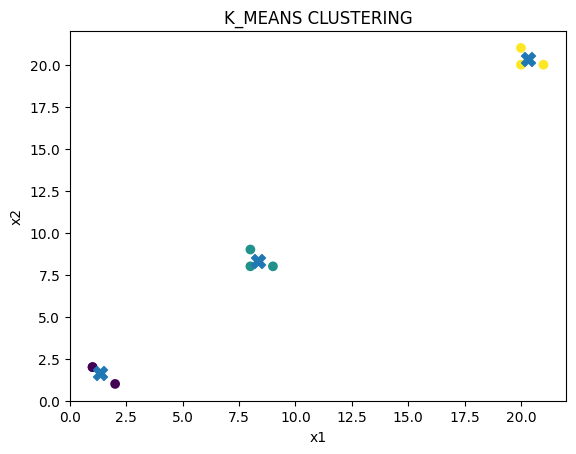

In [17]:
import matplotlib.pyplot as plt
plt.scatter(x[:,0],x[:,1],c=clusters)
plt.scatter(centroids[:,0],centroids[:,1],marker='X',s=100)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("K_MEANS CLUSTERING")
plt.show()